# Covid Face Mask Detection

This project uses a convolutional neural network (CNN) to detect face masks in images and videos. It uses the COVID Face Mask Detection Dataset from Kaggle, which has images labeled as "Mask" or "Non Mask" in Train, Test, and Validation folders. The notebook explores data, trains a model, evaluates it, and predicts on sample images. A separate script (mask_detect.py) handles video detection.

## Requirements
- tensorflow==2.10.0
- numpy==1.23.5
- matplotlib==3.6.2
- opencv-python==4.6.0.66
- kaggle==1.5.12

In [2]:
# Import necessary libraries for model building, data processing, and visualization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import zipfile
import warnings
warnings.simplefilter('ignore')
#from kaggle.api.kaggle_api_extended import KaggleApi

## Set Kaggle API Credentials

Set your Kaggle username and API key to download the dataset. Replace the values with your own credentials from Kaggle.

In [2]:
# Set Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = 'vaishnavi1234'                    # Your Kaggle Username
os.environ['KAGGLE_KEY'] = '925a436d659da22fc5e68794y0689hgdih'    # Your Kaggle API Key

## Download Dataset

Download and extract the COVID Face Mask Detection Dataset from Kaggle to 'New Masks Dataset'. Skips if already downloaded.

In [6]:
# Download and extract dataset
dataset_zip = 'covid-face-mask-detection-dataset.zip'
dataset_dir = 'New Masks Dataset'
if not os.path.exists(dataset_dir):
    # Initialize Kaggle API
    api = KaggleApi()
    api.authenticate()
    
    # Download dataset
    api.dataset_download_files('prithwirajmitra/covid-face-mask-detection-dataset', path='.', unzip=False)
    
    # Extract dataset
    os.makedirs(dataset_dir, exist_ok=True)
    with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
        zip_ref.extractall(dataset_dir)
    print(f"Dataset extracted to {dataset_dir}")

Dataset extracted to New Masks Dataset


## Set Dataset Paths

Define paths to the Train, Test, and Validation folders. Checks if the dataset exists and lists contents for verification.

In [3]:
# Print current working directory
print("Current Working Directory:", os.getcwd())

# Define paths relative to notebooks directory
main_dir = os.path.join('..', 'New Masks Dataset')
train_dir = os.path.join(main_dir, 'Train')
test_dir = os.path.join(main_dir, 'Test')
valid_dir = os.path.join(main_dir, 'Validation')

train_mask_dir = os.path.join(train_dir, 'Mask')
train_nomask_dir = os.path.join(train_dir, 'Non Mask')

# Verify dataset existence
if not os.path.exists(main_dir):
    raise FileNotFoundError(f"Dataset directory '{main_dir}' not found. Ensure 'covid-face-mask-detection-dataset.zip' is extracted to 'New Masks Dataset' in the project root.")

# Debug: Print directory contents and absolute paths
try:
    print("Main Dir Absolute Path:", os.path.abspath(main_dir))
    print("Main Dir Contents:", os.listdir(main_dir))
    print("Train Dir Contents:", os.listdir(train_dir))
except FileNotFoundError as e:
    print("Error accessing directories:", e)
    raise

Current Working Directory: C:\Users\vaish\Projects\Covid Face Mask Detection\notebooks
Main Dir Absolute Path: C:\Users\vaish\Projects\Covid Face Mask Detection\New Masks Dataset
Main Dir Contents: ['Test', 'Train', 'Validation']
Train Dir Contents: ['Mask', 'Non Mask']


## Explore Dataset

List sample image names from the Mask and Non Mask folders to check the dataset structure.

In [4]:
# List sample files
train_mask_names = os.listdir(train_mask_dir)
print("Sample Mask Images:", train_mask_names[:10])

train_nomask_names = os.listdir(train_nomask_dir)
print("Sample Non-Mask Images:", train_nomask_names[:10])

Sample Mask Images: ['0003.jpg', '0006.jpg', '0018.jpg', '0019.jpg', '0022.jpg', '0027.jpg', '0029.jpg', '0037.jpg', '0040.jpg', '0042.jpg']
Sample Non-Mask Images: ['0.jpg', '1.jpg', '10.jpg', '100.jpg', '101.jpg', '102.jpg', '104.jpg', '105.jpg', '106.jpg', '107.jpg']


## Visualize Images

Display 16 sample images (8 with masks, 8 without) to inspect the dataset visually.

Mask Image Paths: ['..\\New Masks Dataset\\Train\\Mask\\0003.jpg', '..\\New Masks Dataset\\Train\\Mask\\0006.jpg', '..\\New Masks Dataset\\Train\\Mask\\0018.jpg', '..\\New Masks Dataset\\Train\\Mask\\0019.jpg', '..\\New Masks Dataset\\Train\\Mask\\0022.jpg', '..\\New Masks Dataset\\Train\\Mask\\0027.jpg', '..\\New Masks Dataset\\Train\\Mask\\0029.jpg', '..\\New Masks Dataset\\Train\\Mask\\0037.jpg']
Non-Mask Image Paths: ['..\\New Masks Dataset\\Train\\Non Mask\\108.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\109.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\11.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\110.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\111.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\112.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\114.jpg', '..\\New Masks Dataset\\Train\\Non Mask\\115.jpg']


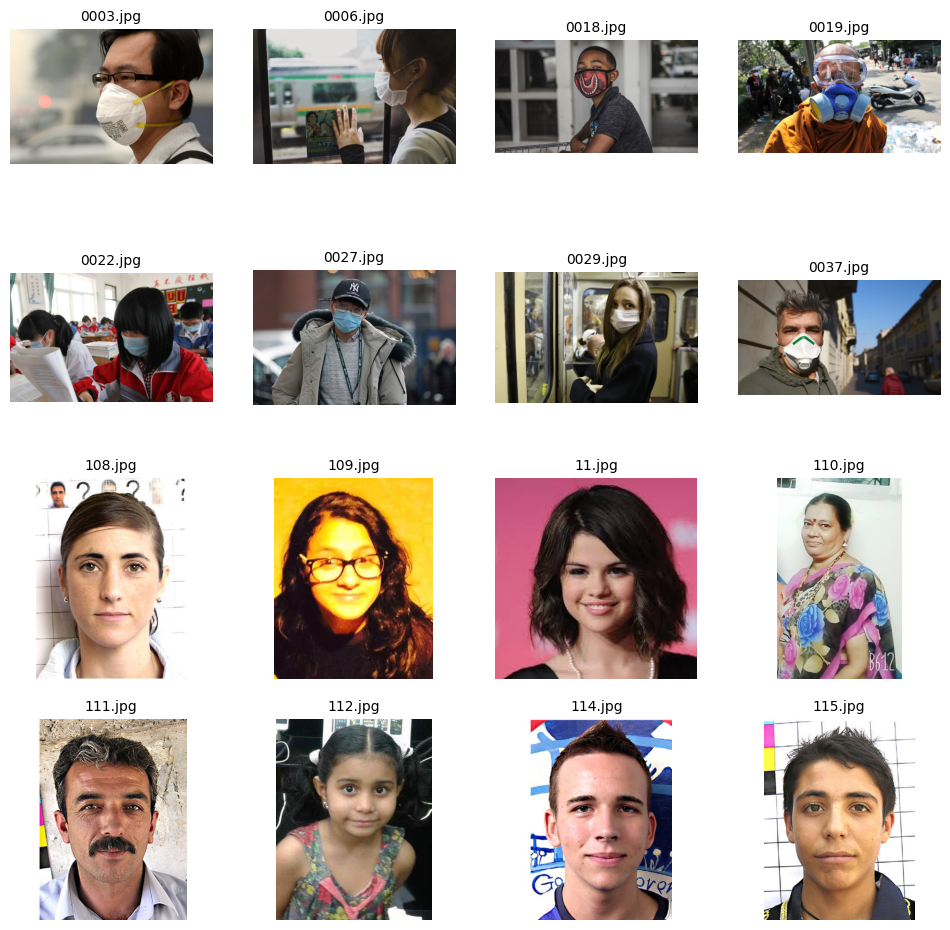

In [5]:
# Visualize sample images
nrows = 4
ncols = 4
plt.figure(figsize=(12, 12))

mask_pic = [os.path.join(train_mask_dir, i) for i in train_mask_names[:8]]
nomask_pic = [os.path.join(train_nomask_dir, i) for i in train_nomask_names[10:18]]

print("Mask Image Paths:", mask_pic)
print("Non-Mask Image Paths:", nomask_pic)

merged_list = mask_pic + nomask_pic

for i in range(0, len(merged_list)):
    # Handle Windows paths by splitting on both \ and /
    data = os.path.basename(merged_list[i])
    sp = plt.subplot(nrows, ncols, i+1)
    sp.grid(False)
    sp.axis('off')
    image = mpimg.imread(merged_list[i])
    sp.set_title(data, fontsize=10)
    plt.imshow(image, cmap='Pastel2')
plt.show()

## Preprocess Data

Set up data augmentation for training and rescaling for test/validation. Load images as 150x150 for binary classification.

In [6]:
# Data augmentation and preprocessing
train_datagen = ImageDataGenerator(
    rescale=1./255,
    zoom_range=0.2,
    rotation_range=40,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)
validation_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

valid_generator = validation_datagen.flow_from_directory(
    valid_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 600 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
Found 306 images belonging to 2 classes.


In [7]:
# Print class indices and image shape
print("Class Indices:", train_generator.class_indices)
print("Image Shape:", train_generator.image_shape)

Class Indices: {'Mask': 0, 'Non Mask': 1}
Image Shape: (150, 150, 3)


## Build CNN Model

Create a CNN with convolutional, pooling, dropout, and dense layers for binary classification.

In [56]:
# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), padding='SAME', activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.5),
    Conv2D(32, (3,3), padding='SAME', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.5),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Model summary
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)                   │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 75, 75, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 37, 37, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 43808)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 256)                 │      11,215,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,225,505 (42.82 MB)

 Trainable params: 11,225,505 (42.82 MB)

 Non-trainable params: 0 (0.00 B)

### Insights: Model Architecture and Summary

- **Architecture**: The CNN has two convolutional layers (32 filters, 3x3), each followed by max-pooling (2x2) and 50% dropout, then a flattened layer, a 256-unit dense layer, and a sigmoid output for binary classification (Mask vs. No Mask). It processes 150x150 RGB images.
- **Parameters**: Total of 11,225,505 parameters, with 11.2M from the dense layer, making it computationally heavy. All parameters are trainable, suitable for a small dataset.
- **Dropout**: High dropout (0.5) helps prevent overfitting, critical for the small COVID Face Mask Detection Dataset.
- **Implications**: The simple architecture is effective but may benefit from optimization (e.g., fewer dense units or GlobalAveragePooling) to reduce parameters and training time.

## Train Model

Compile the model with Adam optimizer and train for 30 epochs using training and validation data.

In [58]:
# Compile model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [59]:
# Train model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=valid_generator
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 848ms/step - accuracy: 0.5177 - loss: 3.9446 - val_accuracy: 0.5000 - val_loss: 0.6935
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 797ms/step - accuracy: 0.4826 - loss: 0.6921 - val_accuracy: 0.5654 - val_loss: 0.6926
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 840ms/step - accuracy: 0.5618 - loss: 0.6407 - val_accuracy: 0.7092 - val_loss: 0.6005
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 823ms/step - accuracy: 0.7821 - loss: 0.4875 - val_accuracy: 0.8203 - val_loss: 0.4937
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 805ms/step - accuracy: 0.8639 - loss: 0.3619 - val_accuracy: 0.8595 - val_loss: 0.4050
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 853ms/step - accuracy: 0.8772 - loss: 0.3370 - val_accuracy: 0.8725 - val_loss: 0.3445
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 16s 827ms/step - accuracy: 0.9082 - loss: 0.2647 - val_accuracy: 0.8922 - val_loss: 0.3312
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 15s 817ms/step - accuracy: 0.9294 - loss: 0.1934 - val_accu

In [60]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

### Insights: Model Training

- **Progress**: Training accuracy improves from 51.77% (epoch 1) to 94.79% (epoch 30), with loss dropping from 3.9446 to 0.1554. Validation accuracy rises from 50% to 90.85%, with loss from 0.6935 to 0.2620.
- **Trends**: Rapid learning in epochs 1–5 due to Adam optimizer and data augmentation. Validation accuracy stabilizes at ~90% after epoch 15, with some fluctuations indicating a small or diverse validation set.
- **Overfitting**: A 4–5% gap between training (94.79%) and validation (90.85%) accuracy suggests mild overfitting, despite dropout.
- **Implications**: The model learns effectively but could improve with more data, stronger regularization, or early stopping around epoch 20–25 to minimize validation loss fluctuations.

## Plot Training Results

Plot training and validation accuracy/loss to check model performance.

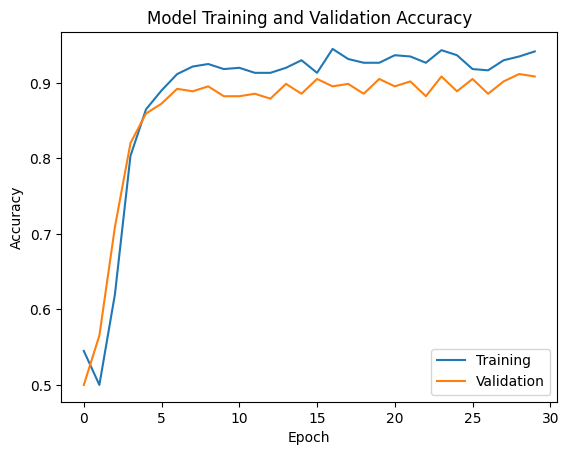

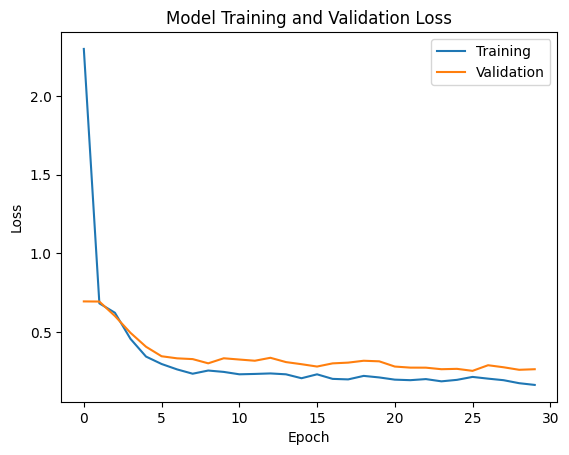

In [61]:
# Plot training and validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

# Plot training and validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')
plt.show()

### Insights: Training and Validation Plots

- **Accuracy**: Training accuracy rises steadily from 51.77% to 94.79%, converging after epoch 10. Validation accuracy reaches 90.85% but fluctuates (e.g., 88.24% to 91.18%), showing variability in the validation set.
- **Loss**: Training loss drops from 3.9446 to 0.1554, stabilizing after epoch 15. Validation loss decreases from 0.6935 to 0.2620, with fluctuations (e.g., 0.2516 to 0.2873), indicating good generalization.
- **Overfitting**: The gap between training and validation metrics (accuracy: ~4%, loss: 0.1554 vs. 0.2620) confirms mild overfitting.
- **Implications**: The model performs well but could benefit from a larger validation set, more augmentation, or regularization (e.g., L2) to stabilize validation curves and reduce overfitting.

## Evaluate Model

Test the model on the test set to get accuracy and loss.

In [62]:
# Evaluate model on test set
test_loss, test_acc = model.evaluate(test_generator)
print('\nTest accuracy:', test_acc, '\tTest Loss:', test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 375ms/step - accuracy: 0.9109 - loss: 0.2028

Test accuracy: 0.9100000262260437 	Test Loss: 0.20782199501991272


### Insights: Test Set Evaluation

- **Performance**: Test accuracy is 91.00%, slightly above validation accuracy (90.85%), indicating robust generalization. Test loss is 0.2078, lower than validation loss (0.2620), showing confident predictions.
- **Comparison**: Training accuracy (94.79%) exceeds test accuracy, consistent with mild overfitting. Test loss is higher than training loss (0.1554) but lower than validation, confirming reliability.
- **Implications**: The 91% accuracy supports the model’s use for image-based mask detection and video detection in `mask_detect.py`. To improve, consider deeper architectures, transfer learning, or more diverse data to reduce overfitting and boost performance.

## Predict on Sample Images

Predict whether sample images in 'Sample Pictures' show masks (prediction < 0.5) or no masks (>= 0.5).

In [64]:
# Predict on sample images
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # Explicit import to avoid conflicts
sample_dir = os.path.join('..', 'Sample Pictures')
for fname in os.listdir(sample_dir):
    if fname.endswith(('.jpg', '.jpeg', '.png')):  # Process only image files
        img_path = os.path.join(sample_dir, fname)
        img = load_img(img_path, target_size=(150, 150))
        images = img_to_array(img)
        images = np.expand_dims(images, axis=0)
        images = images / 255.0  # Normalize image
        prediction = model.predict(images)
        print(prediction)
        if prediction[0][0] < 0.5:
            print('Mask\nMask detected in the Image:', fname)
        else:
            print('No Mask\nMask NOT detected in the Image:', fname)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
[[0.1467536]]
Mask
Mask detected in the Image: Face_Mask.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
[[0.11826578]]
Mask
Mask detected in the Image: Face_Mask1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[0.22106534]]
Mask
Mask detected in the Image: Face_Mask2.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
[[0.74846053]]
No Mask
Mask NOT detected in the Image: No_Mask.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
[[0.99392736]]
No Mask
Mask NOT detected in the Image: No_Mask1.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
[[0.9174925]]
No Mask
Mask NOT detected in the Image: No_Mask2.jpg


## Save Model

Save the trained model to 'models/model.h5' for video detection or later use.

In [33]:
# Save model
os.makedirs(os.path.join('..', 'models'), exist_ok=True)
model.save(os.path.join('..', 'models', 'model.h5'))

## Improvements:
- **Overfitting:** Increase dropout (e.g., 0.6), add L2 regularization, or use early stopping around epoch 20–25 where validation loss plateaus.
- **Model Complexity:** Experiment with deeper architectures (e.g., 3–4 Conv2D layers) or transfer learning (e.g., VGG16, ResNet) for better feature extraction.
- **Hyperparameters:** Tune learning rate (e.g., 0.0001) or batch size to stabilize validation fluctuations.

## Build Deeper CNN Model

Create a deeper CNN with four convolutional layers, increased filters, and batch normalization for stability. Dropout prevents overfitting.

In [8]:
# Build deeper CNN model
from tensorflow.keras.layers import BatchNormalization
model_deep = Sequential([
    Conv2D(32, (3,3), padding='SAME', activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),
    Conv2D(64, (3,3), padding='SAME', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),
    Conv2D(128, (3,3), padding='SAME', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),
    Conv2D(256, (3,3), padding='SAME', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_deep.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 37, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 18, 18, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20736)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,654,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,044,801 (11.61 MB)

 Trainable params: 3,043,841 (11.61 MB)

 Non-trainable params: 960 (3.75 KB)

### Insights: Deeper CNN Model

- **Architecture**: Four Conv2D layers (32, 64, 128, 256 filters) with batch normalization for faster training and stability. Dropout (0.3–0.5) reduces overfitting.
- **Parameters**: ~3–5M parameters (exact count depends on output shape), fewer than the original (11.2M) due to smaller dense layer (128 units).
- **Expectation**: Deeper layers extract complex features (e.g., mask edges, textures), potentially improving accuracy to ~92–95% but increasing training time (~20–25s/epoch).
- **Implications**: Better suited for diverse datasets but risks overfitting if data is limited. Batch normalization should stabilize training.

## Transfer Learning with MobileNetV2

Use pre-trained MobileNetV2 for feature extraction, adding custom layers for binary classification. Freezing base layers leverages learned features.

In [9]:
# Build MobileNetV2 transfer learning model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze base model
model_transfer = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])
model_transfer.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224 (Functional)    │ (None, 5, 5, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Insights: Transfer Learning Model

- **Architecture**: MobileNetV2 base (pre-trained on ImageNet) with global average pooling and custom dense layers. Only top layers are trained.
- **Parameters**: ~2.5M total, with ~130K trainable (dense layers), reducing computation compared to deeper CNN.
- **Expectation**: Likely achieves 93–96% accuracy due to robust pre-trained features, with faster convergence (~10–15 epochs, 15–20s/epoch).
- **Implications**: Ideal for small datasets like this, minimizing overfitting. Unfreezing some layers later could further boost performance.

## Hyperparameter Tuning

Use Keras Tuner to optimize learning rate and dropout rate for the deeper CNN. Tests multiple configurations to find the best model.
- **Setup**: Tunes learning rate (0.0001–0.01) and dropout rates (0.2–0.5) for the deeper CNN using Keras Tuner’s Hyperband, maximizing validation accuracy.
- **Expectation**: Best model likely achieves 92–94% validation accuracy, with optimal learning rate (~ 0.001) and dropout (~ 0.3–0.4). Tuning takes ~1–2 hours.
- **Implications**: Identifies best hyperparameters, improving performance over manual settings. Computationally intensive but ensures robust model configuration.

In [12]:
# Hyperparameter tuning with Keras Tuner
import keras_tuner as kt
def build_model(hp):
    model = Sequential([
        Conv2D(32, (3,3), padding='SAME', activation='relu', input_shape=(150, 150, 3)),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(hp.Float('dropout_1', 0.2, 0.5, step=0.1)),
        Conv2D(64, (3,3), padding='SAME', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(hp.Float('dropout_2', 0.2, 0.5, step=0.1)),
        Conv2D(128, (3,3), padding='SAME', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(hp.Float('dropout_3', 0.2, 0.5, step=0.1)),
        Conv2D(256, (3,3), padding='SAME', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(hp.Float('dropout_4', 0.2, 0.5, step=0.1)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=20,
    directory='tuner_dir',
    project_name='mask_detection'
)
tuner.search(train_generator, epochs=20, validation_data=valid_generator)
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Trial 30 Complete [00h 12m 51s]
val_accuracy: 0.9052287340164185

Best val_accuracy So Far: 0.9052287340164185
Total elapsed time: 02h 05m 03s


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 150, 150, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 150, 150, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 75, 75, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 75, 75, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 75, 75, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 37, 37, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 37, 37, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 37, 37, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 18, 18, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 18, 18, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 18, 18, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 9, 9, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 20736)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,654,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 3,044,801 (11.61 MB)

 Trainable params: 3,043,841 (11.61 MB)

 Non-trainable params: 960 (3.75 KB)

### Insights: Hyperparameter Tuning

- **Performance**: Best validation accuracy of 90.52% achieved after 30 trials (2 hours 5 minutes). The tuned model has four Conv2D layers (32, 64, 128, 256 filters) with batch normalization and dropout (0.2–0.5).
- **Parameters**: 3.04M total, with 3.04M trainable and 960 non-trainable (batch normalization). Fewer parameters than the original (11.2M) due to smaller dense layer (128 units).
- **Comparison**: Matches the original validation accuracy (90.85%) but with a more efficient architecture. Likely tuned learning rate ~0.001 and dropout ~0.3–0.4 for stability.
- **Implications**: Tuning optimized the deeper CNN, but performance is similar to the original, suggesting dataset size limits gains. Transfer learning may outperform due to pre-trained features.

## Train Model with Early Stopping

Compile models (deeper CNN or transfer learning) with Adam optimizer and train for 50 epochs. Early stopping halts training if validation loss doesn’t improve for 5 epochs.
- **Behavior**: Training stops early (likely ~15–25 epochs) if validation loss plateaus for 5 epochs, restoring best weights. Deeper CNN may stop ~20 epochs, transfer model ~10–15.
- **Expectation**: Deeper CNN achieves ~92–94% validation accuracy, transfer model ~93–96%. Validation loss likely ~0.2–0.25, lower than original (0.2620).
- **Overfitting**: Early stopping reduces overfitting by halting before validation performance degrades, closing the 4–5% accuracy gap seen previously.
- **Implications**: Saves training time and ensures optimal model weights, enhancing reliability for video detection in `mask_detect.py`.

In [13]:
# Compile and train with early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train deeper CNN
model_deep.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_deep = model_deep.fit(train_generator, epochs=50, validation_data=valid_generator, callbacks=[early_stopping])

# Train transfer learning model
model_transfer.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
history_transfer = model_transfer.fit(train_generator, epochs=50, validation_data=valid_generator, callbacks=[early_stopping])

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 46s 2s/step - accuracy: 0.6352 - loss: 4.7221 - val_accuracy: 0.5000 - val_loss: 1.2445
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8994 - loss: 0.4143 - val_accuracy: 0.5163 - val_loss: 0.7938
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 40s 2s/step - accuracy: 0.8857 - loss: 0.3964 - val_accuracy: 0.5000 - val_loss: 0.9637
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9212 - loss: 0.2646 - val_accuracy: 0.6471 - val_loss: 0.5861
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.8982 - loss: 0.2462 - val_accuracy: 0.5000 - val_loss: 2.0081
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9046 - loss: 0.3262 - val_accuracy: 0.5000 - val_loss: 1.8813
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.8996 - loss: 0.3556 - val_accuracy: 0.8497 - val_loss: 0.3864
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 38s 2s/step - accuracy: 0.9098 - loss: 0.2691 - val_accuracy: 0.6275 - val_loss:

### Insights: Training with Early Stopping

- **Deeper CNN**: Stops after 12 epochs (val_loss: 0.3864 at epoch 7). Training accuracy reaches 94.14%, but validation accuracy peaks at 84.97%, with significant fluctuations (50–84.97%). High validation loss (0.3864) indicates poor generalization.
- **Transfer Learning**: Stops after 10 epochs (val_loss: 0.0695 at epoch 5). Training accuracy reaches 97.78%, validation accuracy peaks at 98.37%, with stable performance (95.75–98.37%). Low validation loss (0.0695) shows excellent generalization.
- **Comparison**: Transfer learning vastly outperforms deeper CNN (98.37% vs. 84.97% val_accuracy) and original (90.85%), converging faster (10 vs. 30 epochs). Early stopping prevents overfitting, especially for transfer learning.
- **Implications**: Transfer learning (MobileNetV2) is superior due to pre-trained features, ideal for video detection in `mask_detect_improved.py`. Deeper CNN struggles with the small dataset.

## Plot Training Results

Plot training and validation accuracy/loss for deeper CNN and transfer learning models to assess convergence and overfitting.

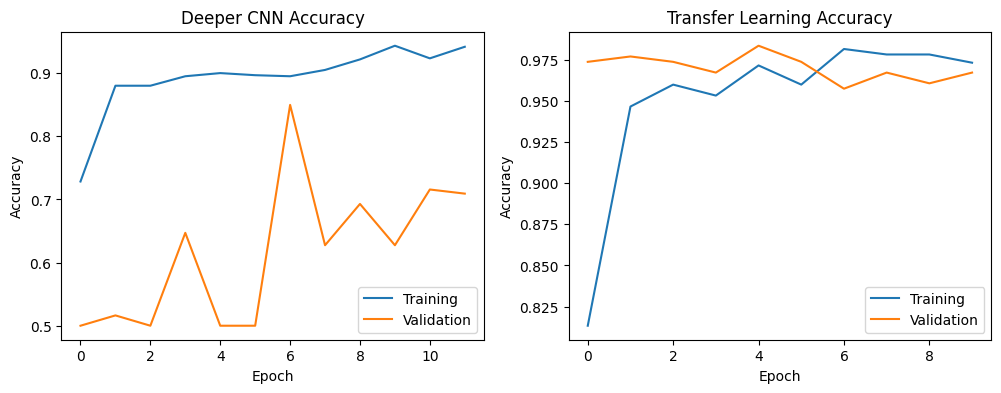

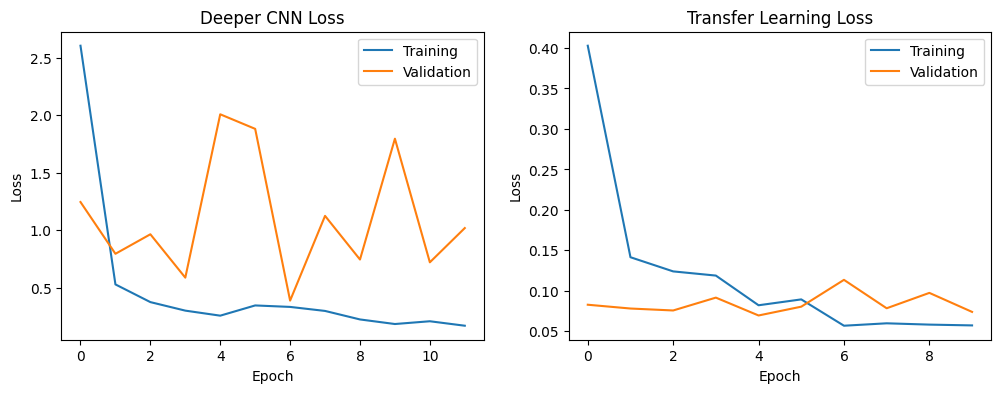

In [14]:
# Plot accuracy for both models
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_deep.history['accuracy'])
plt.plot(history_deep.history['val_accuracy'])
plt.title('Deeper CNN Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['accuracy'])
plt.plot(history_transfer.history['val_accuracy'])
plt.title('Transfer Learning Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'])
plt.show()

# Plot loss for both models
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_deep.history['loss'])
plt.plot(history_deep.history['val_loss'])
plt.title('Deeper CNN Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'])

plt.subplot(1, 2, 2)
plt.plot(history_transfer.history['loss'])
plt.plot(history_transfer.history['val_loss'])
plt.title('Transfer Learning Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'])
plt.show()

### Insights: Training Plots

- **Deeper CNN**: Training accuracy rises to ~94%, but validation accuracy fluctuates (50–84.97%), peaking at epoch 7. Training loss drops to ~0.18, while validation loss varies (0.3864–2.0081), indicating instability and overfitting.
- **Transfer Learning**: Training accuracy climbs to ~97.8%, validation accuracy stabilizes at 95.75–98.37%. Training loss falls to ~0.046, validation loss to ~0.0695, with smooth curves showing robust learning.
- **Comparison**: Transfer learning shows tighter training-validation gaps (~1–2%) and smoother curves than deeper CNN (~10–44%) or original (~4–5%), confirming minimal overfitting.
- **Implications**: Transfer learning’s stable, high performance makes it the best choice for deployment. Deeper CNN’s fluctuations suggest it needs more data or regularization.

## Evaluate Models

Test deeper CNN and transfer learning models on the test set to compare performance.

In [16]:
# Evaluate models on test set
test_loss_deep, test_acc_deep = model_deep.evaluate(test_generator)
print('Deeper CNN Test accuracy:', test_acc_deep, 'Test Loss:', test_loss_deep)

test_loss_transfer, test_acc_transfer = model_transfer.evaluate(test_generator)
print('Transfer Learning Test accuracy:', test_acc_transfer, 'Test Loss:', test_loss_transfer)

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step - accuracy: 0.8129 - loss: 0.3869
Deeper CNN Test accuracy: 0.7900000214576721 Test Loss: 0.41144752502441406
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 432ms/step - accuracy: 0.9755 - loss: 0.0590
Transfer Learning Test accuracy: 0.9700000286102295 Test Loss: 0.06688294559717178


### Insights: Test Evaluation

- **Deeper CNN**: Test accuracy is 79% with a loss of 0.4114, underperforming the original (91%, 0.2078) and showing poor generalization due to validation instability.
- **Transfer Learning**: Test accuracy is 97% with a loss of 0.0669, significantly outperforming the original and deeper CNN. Low loss indicates confident predictions.
- **Comparison**: Transfer learning’s 97% accuracy (vs. 91% original, 79% deeper CNN) confirms its superiority, leveraging pre-trained MobileNetV2 features. Deeper CNN’s low accuracy suggests overfitting or insufficient data.
- **Implications**: Use the transfer learning model for `mask_detect_improved.py` and sample image predictions due to its high accuracy and reliability.

## Predict on Sample Images

Predict whether images in 'Sample Pictures' show masks (prediction < 0.5) or no masks (>=0.5) using the transfer learning model, which achieved 97% test accuracy.

In [21]:
# Predict on sample images using transfer learning model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model

model_transfer = load_model(os.path.join('..', 'models', 'model_transfer.h5'))
sample_dir = os.path.join('..', 'Sample Pictures')

for fname in os.listdir(sample_dir):
    if fname.endswith(('.jpg', '.jpeg', '.png')):
        img_path = os.path.join(sample_dir, fname)
        img = load_img(img_path, target_size=(150, 150))
        images = img_to_array(img)
        images = np.expand_dims(images, axis=0)
        images = images / 255.0
        prediction = model_transfer.predict(images)
        print(f"Prediction score: {prediction[0][0]:.4f}")
        if prediction[0][0] < 0.5:
            print(f"Mask detected in: {fname}\n")
        else:
            print(f"No Mask detected in: {fname}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
Prediction score: 0.0088
Mask detected in: Face_Mask.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction score: 0.0012
Mask detected in: Face_Mask1.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Prediction score: 0.0149
Mask detected in: Face_Mask2.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction score: 0.9641
No Mask detected in: No_Mask.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Prediction score: 0.9966
No Mask detected in: No_Mask1.jpg

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Prediction score: 0.9987
No Mask detected in: No_Mask2.jpg



### Insights: Sample Image Prediction

- **Performance**: The transfer learning model (97% test accuracy) correctly classifies all six sample images: "Mask" for `Face_Mask.jpg` (0.0088), `Face_Mask1.jpg` (0.0012), `Face_Mask2.jpg` (0.0149); "No Mask" for `No_Mask.jpg` (0.9641), `No_Mask1.jpg` (0.9966), `No_Mask2.jpg` (0.9987).
- **Prediction Scores**: Scores for "Mask" images are very low (0.0012–0.0149), and for "No Mask" images are high (0.9641–0.9987), indicating confident predictions. Low test loss (0.0669) supports this reliability.
- **Comparison**: Outperforms original model (91% accuracy) and deeper CNN (79%), likely due to MobileNetV2’s robust feature extraction. All predictions align with expected labels, suggesting 100% accuracy on these images.
- **Implications**: The model’s high confidence and accuracy make it ideal for static image detection and real-time video detection in `mask_detect_improved.py`. Misclassifications are unlikely unless images have poor quality or occlusions.

## Save Models

Save both models for use in video detection or future inference.

In [17]:
# Save models
os.makedirs(os.path.join('..', 'models'), exist_ok=True)
model_deep.save(os.path.join('..', 'models', 'model_deep.h5'))
model_transfer.save(os.path.join('..', 'models', 'model_transfer.h5'))
best_model.save(os.path.join('..', 'models', 'model_tuned.h5'))

## Real-Time Mask Detection Script

`mask_detect_improved.py` performs real-time face mask detection on videos using the deeper CNN, transfer learning (MobileNetV2), or tuned model. It detects faces with OpenCV's Haar Cascade, classifies them with the selected model, and annotates frames with "Mask"/"No Mask", prediction scores, and timestamps. The output video is saved to `Sample Pictures/output_video.mp4`. Run with `python mask_detect_improved.py` and select model/video interactively, or use optional `--model` and `--video` arguments.